In [1]:
# Step 1 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from scipy.stats import entropy



In [12]:
# Folder containing your images (all 1000 are here)
base_path = '/content/drive/MyDrive/image.orig'

# Check folder exists
if not os.path.exists(base_path):
    raise FileNotFoundError("❌ Folder not found! Check your path.")
else:
    print("✅ Folder found! Example files:", os.listdir(base_path)[:10])

✅ Folder found! Example files: ['162.jpg', '118.jpg', '127.jpg', '125.jpg', '158.jpg', '122.jpg', '10.jpg', '121.jpg', '142.jpg', '168.jpg']


In [13]:
def renyi_entropy(image_array, alpha=2.0):
    """
    Computes Rényi's entropy for a given grayscale image.
    alpha ≠ 1 (if alpha=1, this becomes Shannon entropy).
    """
    hist, _ = np.histogram(image_array.flatten(), bins=256, range=(0, 256), density=True)
    hist = hist[hist > 0]  # remove zeros
    if alpha == 1:
        return entropy(hist, base=2)
    else:
        return (1 / (1 - alpha)) * np.log2(np.sum(hist ** alpha))


In [14]:
# Function to compute entropy for all images
def compute_entropies(folder_path, alpha=2.0):
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    entropies = []
    for img_name in tqdm(image_files, desc=f"Computing Rényi Entropy (α={alpha})"):
        img_path = os.path.join(folder_path, img_name)
        try:
            img = Image.open(img_path).convert('L')  # convert to grayscale
            img_array = np.array(img)
            h = renyi_entropy(img_array, alpha)
            entropies.append(h)
        except Exception as e:
            print(f"⚠️ Error processing {img_name}: {e}")
    return np.array(entropies)



Computing Rényi Entropy (α=2.0): 100%|██████████| 1000/1000 [00:08<00:00, 120.06it/s]



--- Rényi Entropy Summary (α = 2.0) ---
Total images: 1000
Mean entropy: 6.4506
Min entropy:  1.3176
Max entropy:  7.7599


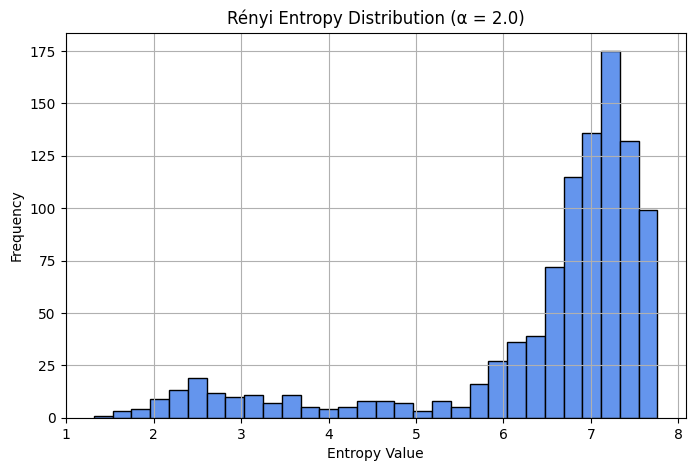

In [15]:
# Try with different alpha values (α = 0.5, 1.0, 2.0, 3.0, etc.)
alpha_value = 2.0

entropies = compute_entropies(base_path, alpha=alpha_value)

# Display summary
print(f"\n--- Rényi Entropy Summary (α = {alpha_value}) ---")
print(f"Total images: {len(entropies)}")
print(f"Mean entropy: {np.mean(entropies):.4f}")
print(f"Min entropy:  {np.min(entropies):.4f}")
print(f"Max entropy:  {np.max(entropies):.4f}")

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(entropies, bins=30, color='cornflowerblue', edgecolor='black')
plt.title(f"Rényi Entropy Distribution (α = {alpha_value})")
plt.xlabel("Entropy Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [16]:
# Define thresholds automatically or manually
low_thr = np.percentile(entropies, 33)
high_thr = np.percentile(entropies, 66)

def classify_by_entropy(h):
    if h < low_thr:
        return 'Low-Entropy Class'
    elif h < high_thr:
        return 'Medium-Entropy Class'
    else:
        return 'High-Entropy Class'

classified = [classify_by_entropy(h) for h in entropies]

unique, counts = np.unique(classified, return_counts=True)
print("\n--- Image Classification based on Entropy ---")
for u, c in zip(unique, counts):
    print(f"{u}: {c} images")



--- Image Classification based on Entropy ---
High-Entropy Class: 340 images
Low-Entropy Class: 330 images
Medium-Entropy Class: 330 images
